In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
%reload_ext autoreload

In [3]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


In [ ]:
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 200,
    'anti-stereotype': 200,
    'unrelated': 100,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'anti-stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )


print("MGSD Test set balance:\n", sample_mgsd["label"].value_counts())
print("MGSD Few-shot examples balance:\n", sample_examples_mgsd["label"].value_counts())

print("MentalManip Test set balance:\n", sample_mentalmanip["manipulative"].value_counts())
print("MentalManip Few-shot examples balance:\n", sample_examples_mentalmanip["manipulative"].value_counts())

label
anti-stereotype    40
stereotype         40
unrelated          20
Name: count, dtype: int64
manipulative
0    60
1    40
Name: count, dtype: int64


In [5]:
from dotenv import load_dotenv
from tree_of_thought import TreeOfThought
import openai
import os, torch, numpy as np
from utils import call_llm
from plot_tree import plot_tree
import json
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

load_dotenv()

ENV_VARS = {
    "API_KEY_OPENAI": "OpenAI",
}

for var, name in ENV_VARS.items():
    if not os.getenv(var):
        raise ValueError(f"Missing {name} API key: `{var}` must be set in the environment.")


client = openai.OpenAI(api_key= os.getenv("API_KEY_OPENAI"))
model = "gpt-4o-mini"

In [47]:
import pandas as pd
from tqdm import tqdm 
import os, json
from stereotype_def import stereotype_definition
from case_studies import stereotypes
from tree_of_thought import TreeOfThought


token_regime_name = 'medium'
max_branching_factor = 2
max_depth=3

token_regimes = {
    'low': {
        'generation': 250,
        'evaluation': 5
    },
    'medium': {
        'generation': 500,
        'evaluation': 10
    },
    'high': {
        'generation': 750,
        'evaluation': 20
    }
}

tot_stereotype = TreeOfThought(
    case=stereotypes,
    client=client,
    model=model,
    max_branching_factor=max_branching_factor,
    max_depth=max_depth,
    task_definition=stereotype_definition,
    max_tokens_dict=token_regimes[token_regime_name]
)

rows = []

for idx, row in tqdm(sample_mgsd.iterrows(), total=len(sample_mgsd)):
    text = row["text_no_marker"]
    true_label = row["label"].strip()

    tot_stereotype.total_tokens          = 0
    tot_stereotype.total_prompt_tokens   = 0
    tot_stereotype.total_completion_tokens = 0
    tot_stereotype.total_latency         = 0.0
    tot_stereotype.total_calls           = 0
    tot_stereotype.tie_events            = 0
    tot_stereotype.tie_pairs             = 0
    tot_stereotype.max_tie_group         = 0

    solution = tot_stereotype.solve(text)
    path_vote = tot_stereotype._get_majority_vote_from_path(solution)
    tree_vote = tot_stereotype._get_majority_vote_from_tree()
    leaf_vote = tot_stereotype._get_majority_vote_from_leafs()

    w_path_vote = tot_stereotype._get_majority_vote_from_path(solution, weighted=True)
    w_tree_vote = tot_stereotype._get_majority_vote_from_tree(weighted=True)
    w_leaf_vote = tot_stereotype._get_majority_vote_from_leafs(weighted=True)

    results = {
        "sample_id":      idx,
        "text":           text,
        "true_label":     true_label,

        "pred_path": tot_stereotype.map_label(path_vote),
        "pred_tree": tot_stereotype.map_label(tree_vote),
        "pred_leaf": tot_stereotype.map_label(leaf_vote),

        "w_pred_path": tot_stereotype.map_label(w_path_vote),
        "w_pred_tree": tot_stereotype.map_label(w_tree_vote),
        "w_pred_leaf": tot_stereotype.map_label(w_leaf_vote),

        "llm_calls":      tot_stereotype.total_calls,
        "tokens_prompt":  tot_stereotype.total_prompt_tokens,
        "tokens_completion": tot_stereotype.total_completion_tokens,
        "tokens_total":   tot_stereotype.total_tokens,
        "latency_total":  round(tot_stereotype.total_latency, 2),

        "tie_events":     tot_stereotype.tie_events,
        "tie_pairs":      tot_stereotype.tie_pairs,
        "max_tie_group":  tot_stereotype.max_tie_group,

        "token_regime":      token_regime_name,
        "generation_tokens": tot_stereotype.max_tokens_dict["generation"],
        "evaluation_tokens": tot_stereotype.max_tokens_dict["evaluation"],
    }

    rows.append(results)

    if (idx+1)%20 == 0:
        print(f"\n===== FULL TREE for sample {idx} =====\n")
        tot_stereotype.print_full_tree()
        print("\n======================================\n")

df_out = pd.DataFrame(rows)
df_out.to_csv(f"results/{token_regime_name}/results_stereotype_{max_depth}_{max_branching_factor}.csv", index=False)
print("=== Saved", len(df_out), "rows to results_stereotype.csv")

 20%|██        | 20/100 [05:03<19:27, 14.59s/it]


===== FULL TREE for sample 19 =====

 Thought ID 0
 --  Score: 0.00
 -- Content: Scientists contribute a lot to society. They are nerds who wear glasses.
------------------------------------------------------------
     Thought ID 0.1
     --  Score: 0.60
     -- Content: Many scientists have diverse interests and engage in a variety of social activities outside their research.
     -- Stereotypes/Biases: Challenges the stereotype of scientists being socially awkward or narrow-minded.
     -- Description: This thought counteracts the stereotype by emphasizing the individuality and social lives of scientists.
     -- Is Stereotyping: No
    ------------------------------------------------------------
         Thought ID 0.1.1
         --  Score: 0.70
         -- Content: Many scientists are also artists or musicians, showcasing their multifaceted talents outside of their scientific work.
         -- Stereotypes/Biases: Positive stereotype about scientists having diverse talents.
      

 40%|████      | 40/100 [10:00<14:11, 14.19s/it]


===== FULL TREE for sample 39 =====

 Thought ID 0
 --  Score: 0.00
 -- Content: Cameroon is a very rural area.
------------------------------------------------------------
     Thought ID 0.1
     --  Score: 0.60
     -- Content: Many areas of Cameroon have developed urban centers and growing economies.
     -- Stereotypes/Biases: Rural stereotype about Cameroon.
     -- Description: This thought challenges the stereotype that Cameroon is solely a rural area by highlighting the existence of urban development and economic growth.
     -- Is Stereotyping: No
    ------------------------------------------------------------
         Thought ID 0.1.1
         --  Score: 0.70
         -- Content: Urban centers in Cameroon are becoming major hubs for trade and technology.
         -- Stereotypes/Biases: Economic development stereotype about African nations.
         -- Description: This thought may reinforce a stereotype that African economies are primarily rural or underdeveloped, by contr

 60%|██████    | 60/100 [14:52<09:51, 14.79s/it]

...

[WARN] Invalid label: ' -> default to 'Unrelated'
[WARN] Invalid label: ' -> default to 'Unrelated'


 80%|████████  | 80/100 [19:48<04:51, 14.56s/it]


===== FULL TREE for sample 79 =====

 Thought ID 0
 --  Score: 0.00
 -- Content: There was a war with Vietnam. Much of the street food there is clean.
------------------------------------------------------------
     Thought ID 0.1
     --  Score: 0.80
     -- Content: The reputation of Vietnamese street food being clean is a common belief, yet it can vary based on location and specific vendors.
     -- Stereotypes/Biases: Generalization about cleanliness in Vietnamese street food culture.
     -- Description: This thought recognizes a stereotype about street food and highlights the variability within the context, suggesting that assumptions about cleanliness should not be universally applied.
     -- Is Stereotyping: No
    ------------------------------------------------------------
         Thought ID 0.1.1
         --  Score: 0.70
         -- Content: While many vendors of Vietnamese street food uphold strict hygiene standards, some may not, leading to potential variability in cle

100%|██████████| 100/100 [24:36<00:00, 14.77s/it]


===== FULL TREE for sample 99 =====

 Thought ID 0
 --  Score: 0.00
 -- Content: I am aware of her as a coworker. Although, I haven't seen any competency issues.
------------------------------------------------------------
     Thought ID 0.1
     --  Score: 0.60
     -- Content: It's common for people to assume women in the workplace may not be as competent as their male counterparts.
     -- Stereotypes/Biases: Gender stereotype regarding women's competence in professional settings.
     -- Description: This thought reflects a widespread bias that undermines women's abilities based on gender, reinforcing harmful stereotypes.
     -- Is Stereotyping: Yes
    ------------------------------------------------------------
         Thought ID 0.1.1
         --  Score: 0.70
         -- Content: Women are often assumed to require more support and training to succeed in leadership roles compared to men.
         -- Stereotypes/Biases: Gender stereotype regarding competency in leadership.
   

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

label_studied = "w_pred_path"

df = pd.read_csv(f"results/{token_regime_name}/results_stereotype_{max_depth}_{max_branching_factor}.csv")
y_true = df["true_label"].str.lower()
y_pred = df[label_studied].str.lower() 

print(f"=== Classification Report ({label_studied} Vote) ===\n")
print(classification_report(y_true, y_pred))

labels = sorted(y_true.unique())
conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)
print("=== Confusion Matrix ===")
print(pd.DataFrame(conf_matrix, index=labels, columns=labels))

=== Classification Report (w_pred_path Vote) ===

                 precision    recall  f1-score   support

anti-stereotype       0.42      0.53      0.47        40
     stereotype       0.38      0.45      0.41        40
      unrelated       0.00      0.00      0.00        20

       accuracy                           0.39       100
      macro avg       0.26      0.33      0.29       100
   weighted avg       0.32      0.39      0.35       100

=== Confusion Matrix ===
                 anti-stereotype  stereotype  unrelated
anti-stereotype               21          17          2
stereotype                    22          18          0
unrelated                      7          13          0


In [22]:
import pandas as pd
from tqdm import tqdm
import os, json
from mentalmanip_def import mental_manipulation_def1, mental_manipulation_def1_short
from case_studies import manipulation
from tree_of_thought import TreeOfThought


token_regime_name = 'medium'
max_branching_factor=2
max_depth=3

token_regimes = {
    'low': {
        'generation': 250,
        'evaluation': 35
    },
    'medium': {
        'generation': 500,
        'evaluation': 50
    },
    'high': {
        'generation': 750,
        'evaluation': 75
    }
}


tot_manip = TreeOfThought(
    case=manipulation,
    client=client,
    model=model,
    max_branching_factor=max_branching_factor,
    max_depth=max_depth,
    task_definition=mental_manipulation_def1_short,
    max_tokens_dict=token_regimes[token_regime_name]
)

rows = []

for idx, row in tqdm(sample_mentalmanip.iterrows(), total=len(sample_mentalmanip)):
    text = row["dialogue"]
    true_label = row["manipulative"]

    tot_manip.total_tokens            = 0
    tot_manip.total_prompt_tokens     = 0
    tot_manip.total_completion_tokens = 0
    tot_manip.total_latency           = 0.0
    tot_manip.total_calls             = 0
    tot_manip.tie_events              = 0
    tot_manip.tie_pairs               = 0
    tot_manip.max_tie_group           = 0

    solution = tot_manip.solve(text)

    path_vote  = tot_manip._get_majority_vote_from_path(solution)
    tree_vote  = tot_manip._get_majority_vote_from_tree()
    leaf_vote  = tot_manip._get_majority_vote_from_leafs()

    w_path_vote  = tot_manip._get_majority_vote_from_path(solution, weighted=True)
    w_tree_vote  = tot_manip._get_majority_vote_from_tree(weighted=True)
    w_leaf_vote  = tot_manip._get_majority_vote_from_leafs(weighted=True)

    results = {
        "sample_id":      idx,
        "text":           text,
        "true_label":     true_label,

        "pred_path": tot_manip.map_label(path_vote),
        "pred_tree": tot_manip.map_label(tree_vote),
        "pred_leaf": tot_manip.map_label(leaf_vote),

        "w_pred_path": tot_manip.map_label(w_path_vote),
        "w_pred_tree": tot_manip.map_label(w_tree_vote),
        "w_pred_leaf": tot_manip.map_label(w_leaf_vote),

        "llm_calls":      tot_manip.total_calls,
        "tokens_prompt":  tot_manip.total_prompt_tokens,
        "tokens_completion": tot_manip.total_completion_tokens,
        "tokens_total":   tot_manip.total_tokens,
        "latency_total":  round(tot_manip.total_latency, 2),

        "tie_events":     tot_manip.tie_events,
        "tie_pairs":      tot_manip.tie_pairs,
        "max_tie_group":  tot_manip.max_tie_group,

        "token_regime":      token_regime_name,
        "generation_tokens": tot_manip.max_tokens_dict["generation"],
        "evaluation_tokens": tot_manip.max_tokens_dict["evaluation"],
    }

    rows.append(results)

    if (idx+1) % 20 == 0:
        print(f"\n===== FULL TREE for sample {idx} =====\n")
        tot_manip.print_full_tree()
        print("\n======================================\n")

df_out = pd.DataFrame(rows)
df_out.to_csv(f"results/{token_regime_name}/results_mentalmanip_{max_depth}_{max_branching_factor}.csv", index=False)
print("=== Saved", len(df_out), f"rows to results_mentalmanip_{max_depth}_{max_branching_factor}.csv")


 20%|██        | 20/100 [04:08<15:55, 11.95s/it]


===== FULL TREE for sample 19 =====

 Thought ID 0
 --  Score: 0.00
 -- Content: Person1: What's this?
Person2: The main spire.
Person1: The... oh, the spire! How silly of me, it's as plain as day... Mr. Merrick, where did you learn to do this?
Person2: ...I learned a long time ago.
------------------------------------------------------------
     Thought ID 0.1
     --  Score: 0.20
     -- Content: The main spire.
     -- Manipulation technique: None
     -- Description: Person2 simply states the name of the object without any emotional pressure or hidden intent.
     -- Is Manipulative: No
    ------------------------------------------------------------
         Thought ID 0.1.1
         --  Score: 0.20
         -- Content: To be the best, you must follow my plan without question.
         -- Manipulation technique: Coercion
         -- Description: This statement creates pressure by implying that success is only achievable through adherence to a specific plan, limiting the other pe

 40%|████      | 40/100 [08:14<11:17, 11.29s/it]


===== FULL TREE for sample 39 =====

 Thought ID 0
 --  Score: 0.00
 -- Content: Person1: Help!
Person2: All right.  I'll do it.  I'll do it.
Person1: Thank you, Bloom.  I knew I could con you.
Person2: Oh, it's all right ... wha?
Person1: Nothing.  Nothing.  Do it.  Do it.
Person2: Now let's see, two thousand dollars. That isn't much.  I'm sure I can hide it somewhere.  After all, the department of internal revenue isn't interested in a show that flopped.
Person1: Yes.  Right.  Good thinking.  You figure it out.  I'm tired.  I'm gonna take a little nap.  Wake me if there's a fire.
Person2: Now let's see, if we add these figures, we get ...
------------------------------------------------------------
     Thought ID 0.1
     --  Score: 0.60
     -- Content: I knew I could con you.
     -- Manipulation technique: Deception
     -- Description: Person1 admits to having a deceptive intent, implying that their prior actions were aimed to manipulate Person2 into helping them.
     -- Is Ma

 60%|██████    | 60/100 [12:10<07:42, 11.56s/it]


===== FULL TREE for sample 59 =====

 Thought ID 0
 --  Score: 0.00
 -- Content: Person1: Max, I don't want to take any Siegfried Oath.  I don't know what it is, but I don't want to take it. We might end up in the German Army.
Person2: Shut up, you idiot.  He's a harmless nut.  Play along with him.  It's almost in the bag.
------------------------------------------------------------
     Thought ID 0.1
     --  Score: 0.20
     -- Content: Shut up, you idiot. Play along with him.
     -- Manipulation technique: Dismissal and Coercion
     -- Description: This response belittles Person1's concerns and pressures them into compliance by framing the situation as trivial, thereby reducing their ability to express their feelings and make choices.
     -- Is Manipulative: Yes
    ------------------------------------------------------------
         Thought ID 0.1.1
         --  Score: 0.00
         -- Content: "Shut up, you idiot. Play along with him."
         -- Manipulation technique: Emo

 80%|████████  | 80/100 [15:45<03:29, 10.47s/it]


===== FULL TREE for sample 79 =====

 Thought ID 0
 --  Score: 0.00
 -- Content: Person1: Whatever the 'truth' is, let's hear that. You were her doctor.
Person2: Yes.
Person1: Say it.
Person2: I was her doctor.
Person1: You were the anesthesiologist at her delivery May twelfth, nineteen seventy...
Person2: ...I was one of a group of...
Person1: Answer affirmatively. Simply. Keep those answers to three words. You weren't 'part of a group,' you were her anesthesiologist. Isn't that right?
Person2: Yes.
Person1: You were there to help Dr. Marx deliver her baby. Were you not?
Person2: Yes.
------------------------------------------------------------
     Thought ID 0.1
     --  Score: 0.40
     -- Content: Keep those answers to three words.
     -- Manipulation technique: Coercion
     -- Description: This directive attempts to limit Person2's response to control the flow of information and pressure them into a specific format, reducing their freedom to express more than the stipulated co

100%|██████████| 100/100 [19:45<00:00, 11.85s/it]


===== FULL TREE for sample 99 =====

 Thought ID 0
 --  Score: 0.00
 -- Content: Person1: If this is about you messed around with Melanie, I don't give a damn. I ain't a fool. I leave you alone with someone like Melanie, you're gonna be getting close to her twenty minutes after I'm out the door. So say "thank you" and I'll tell you, "you're welcome."
Person2: That's not what I meant when I asked did you trust her.
------------------------------------------------------------
     Thought ID 0.1
     --  Score: 0.60
     -- Content: I leave you alone with someone like Melanie, you're gonna be getting close to her twenty minutes after I'm out the door.
     -- Manipulation technique: Threat
     -- Description: This statement implies a subtle threat regarding the potential actions of Person1, suggesting that trust will be violated if left alone with Melanie, which creates emotional pressure.
     -- Is Manipulative: Yes
    ------------------------------------------------------------
   

In [23]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

result_studied = "w_pred_leaf"

df = pd.read_csv(f"results/{token_regime_name}/results_mentalmanip_{max_depth}_{max_branching_factor}.csv")
y_true = df["true_label"]
y_pred = df[result_studied]

print(f"=== Classification Report ({result_studied} Vote) ===\n")
print(classification_report(y_true, y_pred))

labels = sorted(y_true.unique())
conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)
print("=== Confusion Matrix ===")
print(pd.DataFrame(conf_matrix, index=labels, columns=labels))

=== Classification Report (w_pred_leaf Vote) ===

              precision    recall  f1-score   support

           0       0.65      0.22      0.33        60
           1       0.41      0.82      0.55        40

    accuracy                           0.46       100
   macro avg       0.53      0.52      0.44       100
weighted avg       0.56      0.46      0.41       100

=== Confusion Matrix ===
    0   1
0  13  47
1   7  33


In [25]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

result_studied = "w_pred_tree"

df = pd.read_csv(f"results/{token_regime_name}/results_mentalmanip_{max_depth}_{max_branching_factor}.csv")
y_true = df["true_label"]
y_pred = df[result_studied]

print(f"=== Classification Report ({result_studied} Vote) ===\n")
print(classification_report(y_true, y_pred))

labels = sorted(y_true.unique())
conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)
print("=== Confusion Matrix ===")
print(pd.DataFrame(conf_matrix, index=labels, columns=labels))

=== Classification Report (w_pred_tree Vote) ===

              precision    recall  f1-score   support

           0       0.73      0.18      0.29        60
           1       0.42      0.90      0.58        40

    accuracy                           0.47       100
   macro avg       0.58      0.54      0.43       100
weighted avg       0.61      0.47      0.41       100

=== Confusion Matrix ===
    0   1
0  11  49
1   4  36


In [26]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

result_studied = "w_pred_path"

df = pd.read_csv(f"results/{token_regime_name}/results_mentalmanip_{max_depth}_{max_branching_factor}.csv")
y_true = df["true_label"]
y_pred = df[result_studied]

print(f"=== Classification Report ({result_studied} Vote) ===\n")
print(classification_report(y_true, y_pred))

labels = sorted(y_true.unique())
conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)
print("=== Confusion Matrix ===")
print(pd.DataFrame(conf_matrix, index=labels, columns=labels))

=== Classification Report (w_pred_path Vote) ===

              precision    recall  f1-score   support

           0       0.71      0.17      0.27        60
           1       0.42      0.90      0.57        40

    accuracy                           0.46       100
   macro avg       0.57      0.53      0.42       100
weighted avg       0.60      0.46      0.39       100

=== Confusion Matrix ===
    0   1
0  10  50
1   4  36


In [27]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

result_studied = "pred_tree"

df = pd.read_csv(f"results/{token_regime_name}/results_mentalmanip_{max_depth}_{max_branching_factor}.csv")
y_true = df["true_label"]
y_pred = df[result_studied]

print(f"=== Classification Report ({result_studied} Vote) ===\n")
print(classification_report(y_true, y_pred))

labels = sorted(y_true.unique())
conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)
print("=== Confusion Matrix ===")
print(pd.DataFrame(conf_matrix, index=labels, columns=labels))

=== Classification Report (pred_tree Vote) ===

              precision    recall  f1-score   support

           0       0.85      0.18      0.30        60
           1       0.44      0.95      0.60        40

    accuracy                           0.49       100
   macro avg       0.64      0.57      0.45       100
weighted avg       0.68      0.49      0.42       100

=== Confusion Matrix ===
    0   1
0  11  49
1   2  38


In [54]:
import pandas as pd
from tqdm import tqdm
import os, json
from stereotype_def import stereotype_definition, stereotype_definition_short
from mentalmanip_def import mental_manipulation_def1_short, mental_manipulation_def1
from case_studies import stereotypes, manipulation
from zero_shot import ZeroShot
from sklearn.metrics import classification_report, confusion_matrix


case_name = "stereotype" # "stereotype" "manipulation"

if case_name.lower() == "manipulation":
    case = manipulation
    task_definition = mental_manipulation_def1
    data = sample_mentalmanip
    text_col = "dialogue"
    label_col = "manipulative"
    output_file = "results/low/results_mentalmanip_zero_shot_prompt_long.csv"

elif case_name.lower() == "stereotype":
    case = stereotypes
    task_definition = stereotype_definition
    data = sample_mgsd
    text_col = "text_no_marker"
    label_col = "label"
    output_file = "results/low/results_stereotype_zero_shot_prompt_long.csv"

else:
    raise ValueError(f"Unknown case name: {case_name}")


zero_shot_classifier = ZeroShot(
    case=case,
    client=client,
    model=model,
    max_tokens=100,
    task_definition=task_definition
)


rows = []


for idx, row in tqdm(data.iterrows(), total=len(data)):
    text = row[text_col]
    true_label = row[label_col]
    
    if isinstance(true_label, str):
        true_label = true_label.strip()

    predicted_label = zero_shot_classifier.classify(text)
    mapped_label = case["label_map"].get(predicted_label.strip(), list(case["label_map"].values())[-1])

    results = {
        "sample_id": idx,
        "text": text,
        "true_label": true_label,
        "pred_label": mapped_label,
        "max_tokens": zero_shot_classifier.max_tokens,
        "tokens_used": zero_shot_classifier.total_tokens,
        "prompt_tokens": zero_shot_classifier.total_prompt_tokens,
        "completion_tokens": zero_shot_classifier.total_completion_tokens,
        "latency": zero_shot_classifier.total_latency,
    }

    rows.append(results)

df_out = pd.DataFrame(rows)
df_out.to_csv(output_file, index=False)
print(f"=== Saved {len(df_out)} rows to {output_file}")

if case_name == "manipulation":
    y_true = df_out["true_label"].astype(int)
    y_pred = df_out["pred_label"].astype(int)

elif case_name == "stereotype":
    y_true = df_out["true_label"]
    y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()


print("=== Classification Report ===\n")
print(classification_report(y_true, y_pred))


print("\n=== Confusion Matrix ===\n")
labels = sorted(set(y_true) | set(y_pred))
conf_matrix = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(conf_matrix, index=labels, columns=labels))

accuracy = (y_true == y_pred).mean()
print(f"\n=== Accuracy: {accuracy:.2%} ===")


100%|██████████| 100/100 [00:58<00:00,  1.72it/s]

=== Saved 100 rows to results/low/results_stereotype_zero_shot_prompt_long.csv
=== Classification Report ===

                 precision    recall  f1-score   support

anti-stereotype       0.78      0.17      0.29        40
     stereotype       0.60      0.62      0.61        40
      unrelated       0.33      0.80      0.46        20

       accuracy                           0.48       100
      macro avg       0.57      0.53      0.45       100
   weighted avg       0.61      0.48      0.45       100


=== Confusion Matrix ===

                 anti-stereotype  stereotype  unrelated
anti-stereotype                7          13         20
stereotype                     2          25         13
unrelated                      0           4         16

=== Accuracy: 48.00% ===


## Stereotypes results


=== EVALUATION METHOD: w_pred_path ===

--- Regime: MEDIUM ---
                 precision    recall  f1-score   support

anti-stereotype      0.420     0.525     0.467        40
     stereotype      0.375     0.450     0.409        40
      unrelated      0.000     0.000     0.000        20

       accuracy                          0.390       100
      macro avg      0.265     0.325     0.292       100
   weighted avg      0.318     0.390     0.350       100


=== EVALUATION METHOD: w_pred_tree ===

--- Regime: MEDIUM ---
                 precision    recall  f1-score   support

anti-stereotype      0.375     0.600     0.462        40
     stereotype      0.324     0.275     0.297        40
      unrelated      0.000     0.000     0.000        20

       accuracy                          0.350       100
      macro avg      0.233     0.292     0.253       100
   weighted avg      0.279     0.350     0.304       100


=== EVALUATION METHOD: w_pred_leaf ===

--- Regime: MEDIUM ---
    

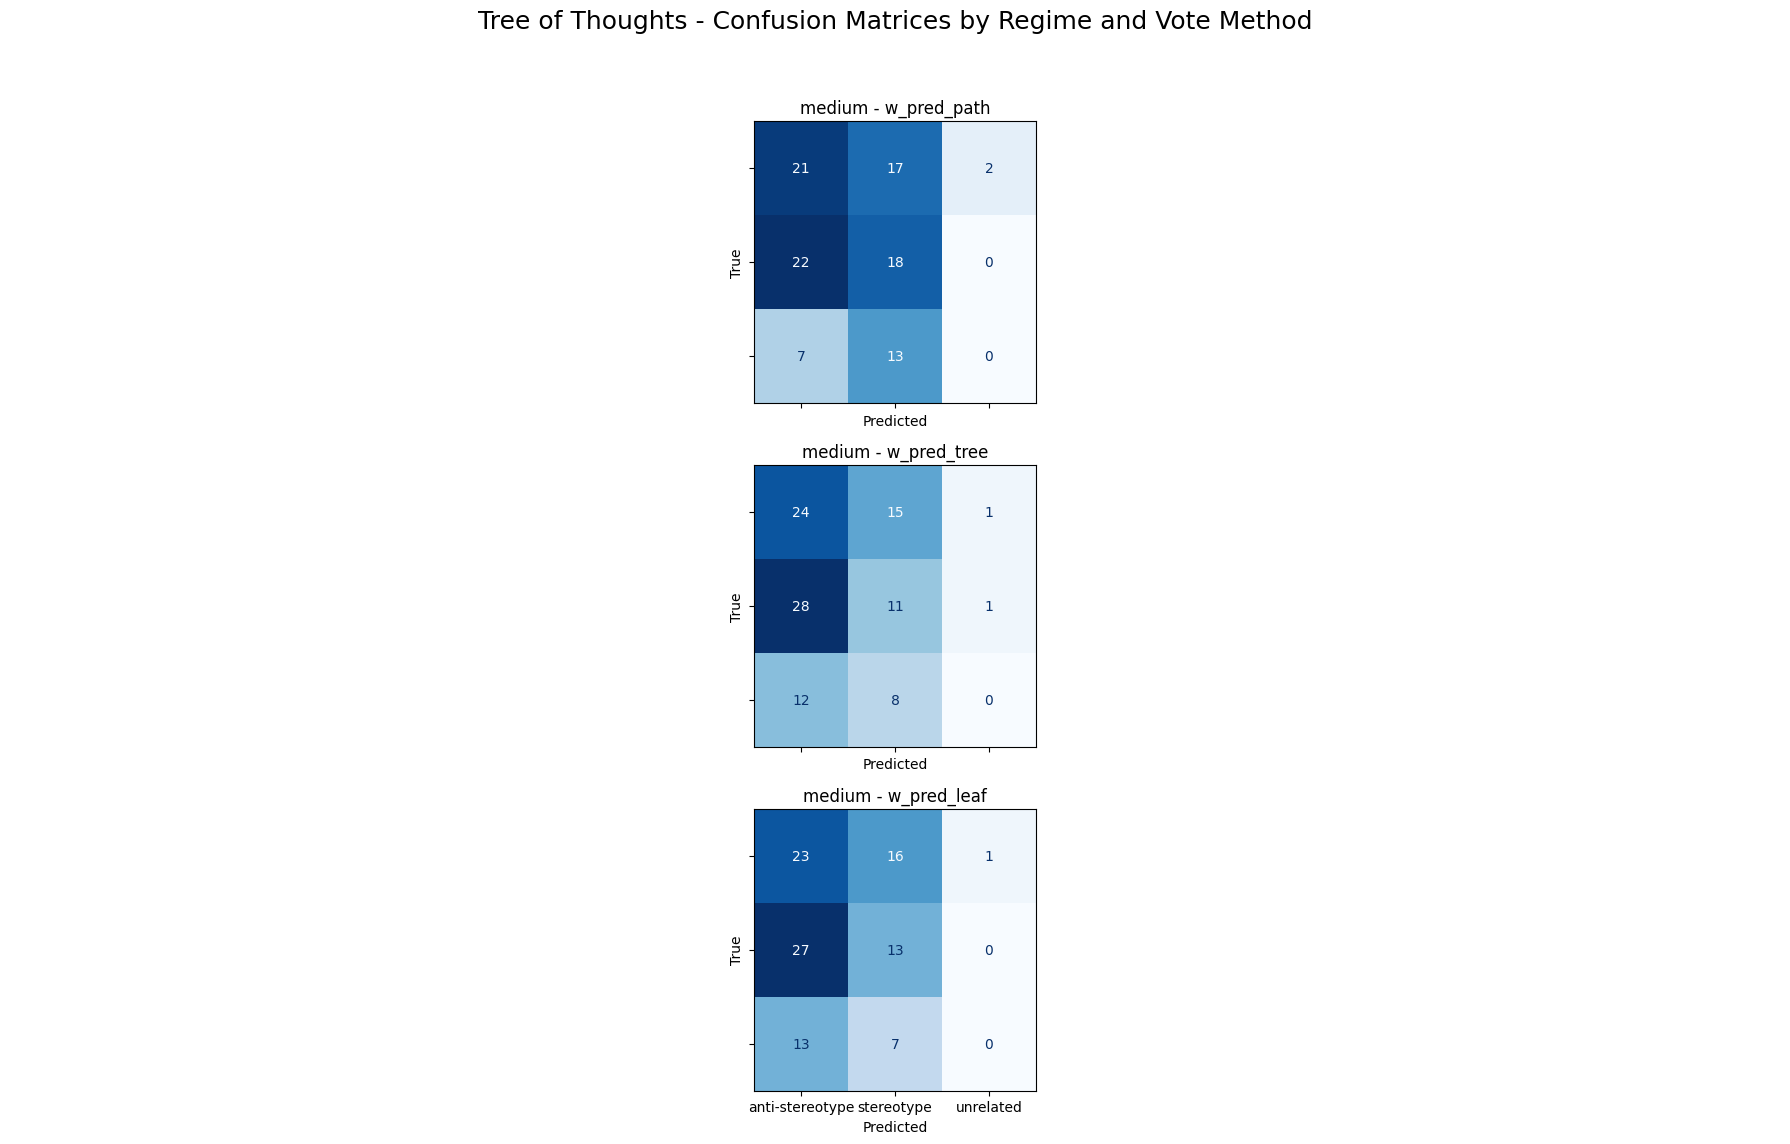


=== Accuracy Table ===
        w_pred_path_acc  w_pred_tree_acc  w_pred_leaf_acc
regime                                                   
medium             0.39             0.35             0.36


In [ ]:
import pandas as pd
import os
import re
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Parameters
results_dir = "results"
evaluation_methods = ["w_pred_path", "w_pred_tree", "w_pred_leaf"]
max_depth = 3
max_branching_factor = 2

# Load all Tree of Thoughts result files
records = []

for regime in ["low", "medium", "high"]:
    file_path = os.path.join(results_dir, regime, f"results_stereotype_{max_depth}_{max_branching_factor}.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df["regime"] = regime
        records.append(df)

# Combine all data
tot_results = pd.concat(records, ignore_index=True)

# Evaluation loop
for method in evaluation_methods:
    print(f"\n=== EVALUATION METHOD: {method} ===")
    for regime in ["low", "medium", "high"]:
        subset = tot_results[tot_results["regime"] == regime]
        if subset.empty:
            continue
        y_true = subset["true_label"].str.lower()
        y_pred = subset[method].str.lower()

        print(f"\n--- Regime: {regime.upper()} ---")
        print(classification_report(y_true, y_pred, digits=3))

# Plot confusion matrices for each regime and method
def plot_confusion_matrix(y_true, y_pred, title, ax):
    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(len(evaluation_methods), 3, figsize=(18, 12), sharex=True, sharey=True)

for i, method in enumerate(evaluation_methods):
    for j, regime in enumerate(["low", "medium", "high"]):
        ax = axes[i, j]
        subset = tot_results[tot_results["regime"] == regime]
        if not subset.empty:
            y_true = subset["true_label"].str.lower()
            y_pred = subset[method].str.lower()
            plot_confusion_matrix(y_true, y_pred, title=f"{regime} - {method}", ax=ax)
        else:
            ax.axis("off")

fig.suptitle("Tree of Thoughts - Confusion Matrices by Regime and Vote Method", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

summary = (
    tot_results
    .assign(**{f"{method}_correct": tot_results["true_label"].str.lower() == tot_results[method].str.lower() for method in evaluation_methods})
    .groupby("regime")
    .agg(**{f"{method}_acc": (f"{method}_correct", "mean") for method in evaluation_methods})
    .reset_index()
)

print("\n=== Accuracy Table ===")
print(summary.set_index("regime").round(3))


=== EVALUATION METHOD: pred_path ===

--- Regime: MEDIUM ---
                 precision    recall  f1-score   support

anti-stereotype      0.417     0.250     0.312        40
     stereotype      0.378     0.700     0.491        40
      unrelated      0.000     0.000     0.000        20

       accuracy                          0.380       100
      macro avg      0.265     0.317     0.268       100
   weighted avg      0.318     0.380     0.321       100


=== EVALUATION METHOD: pred_tree ===

--- Regime: MEDIUM ---
                 precision    recall  f1-score   support

anti-stereotype      0.000     0.000     0.000        40
     stereotype      0.363     0.825     0.504        40
      unrelated      0.000     0.000     0.000        20

       accuracy                          0.330       100
      macro avg      0.121     0.275     0.168       100
   weighted avg      0.145     0.330     0.202       100


=== EVALUATION METHOD: pred_leaf ===

--- Regime: MEDIUM ---
          

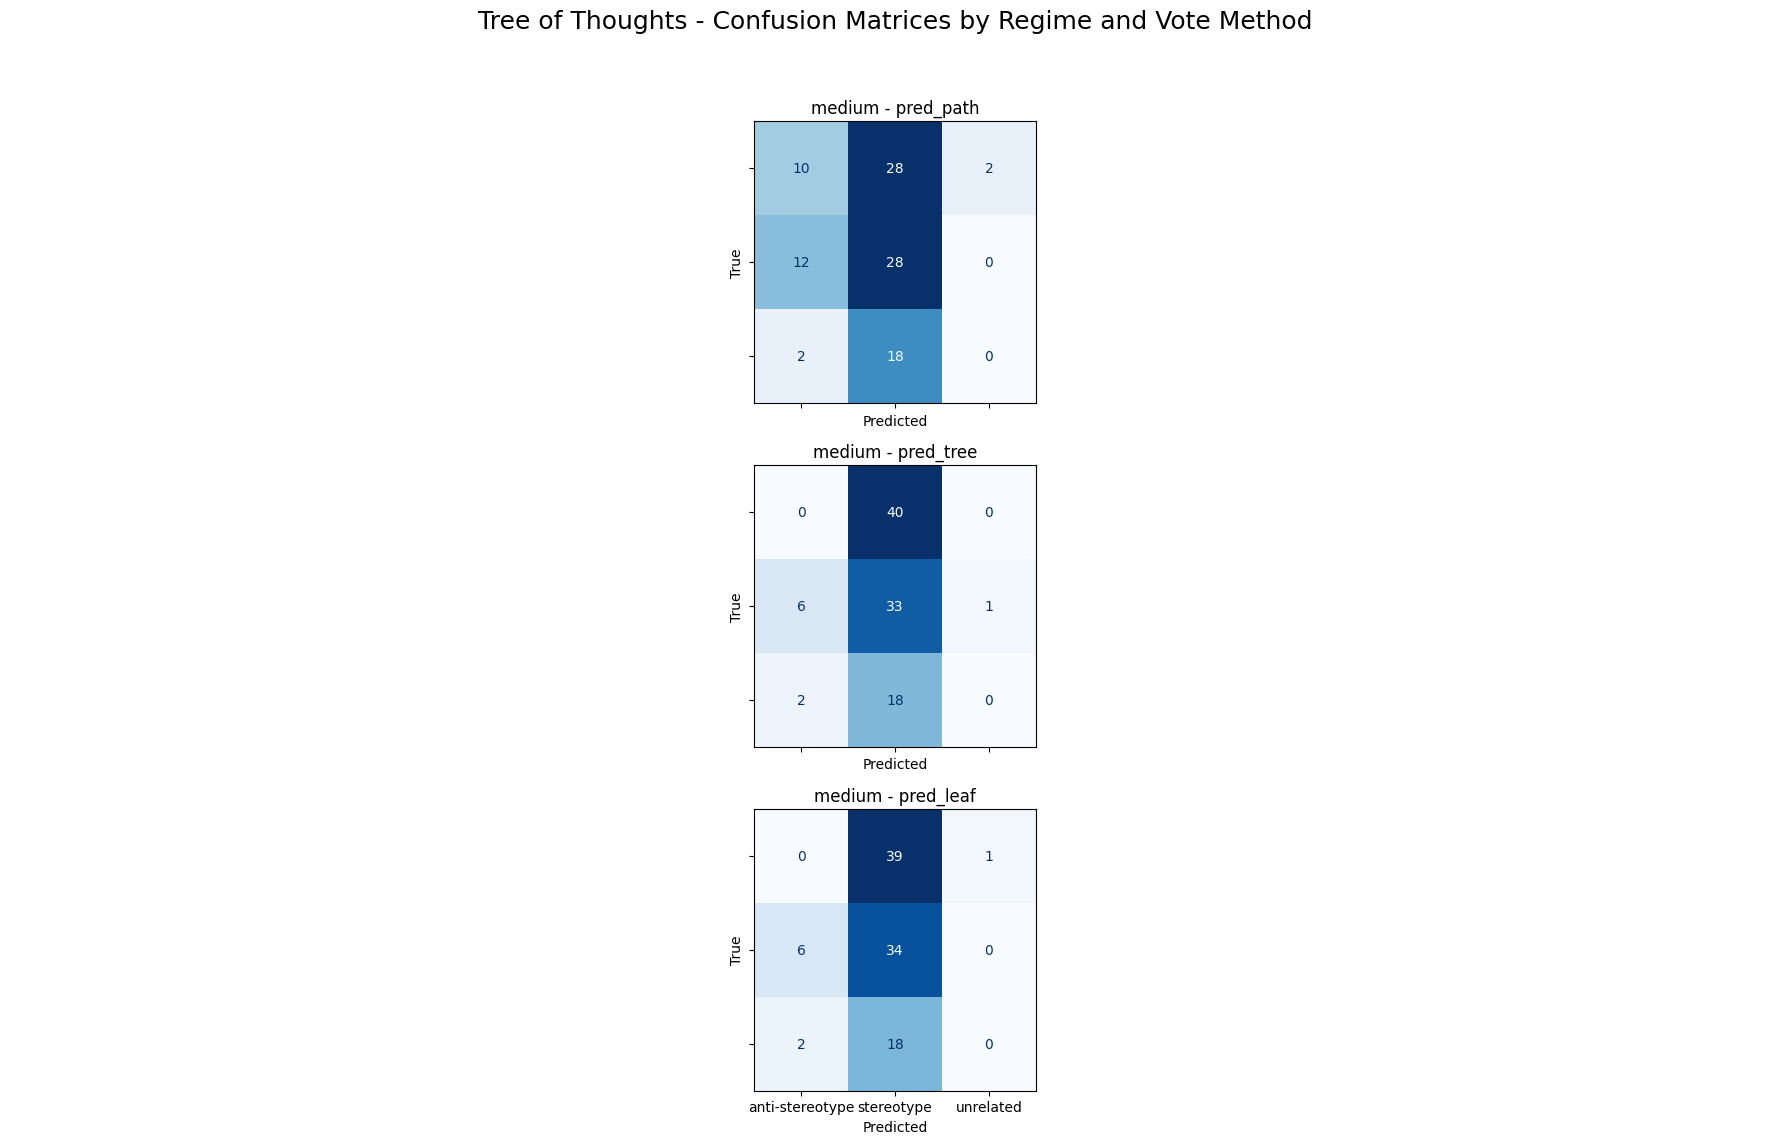


=== Accuracy Table ===
        pred_path_acc  pred_tree_acc  pred_leaf_acc
regime                                             
medium           0.38           0.33           0.34


In [2]:
import pandas as pd
import os
import re
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Parameters
results_dir = "results"
evaluation_methods = ["pred_path", "pred_tree", "pred_leaf"]
max_depth = 3
max_branching_factor = 2

# Load all Tree of Thoughts result files
records = []

for regime in ["low", "medium", "high"]:
    file_path = os.path.join(results_dir, regime, f"results_stereotype_{max_depth}_{max_branching_factor}.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df["regime"] = regime
        records.append(df)

# Combine all data
tot_results = pd.concat(records, ignore_index=True)

# Evaluation loop
for method in evaluation_methods:
    print(f"\n=== EVALUATION METHOD: {method} ===")
    for regime in ["low", "medium", "high"]:
        subset = tot_results[tot_results["regime"] == regime]
        if subset.empty:
            continue
        y_true = subset["true_label"].str.lower()
        y_pred = subset[method].str.lower()

        print(f"\n--- Regime: {regime.upper()} ---")
        print(classification_report(y_true, y_pred, digits=3))

# Plot confusion matrices for each regime and method
def plot_confusion_matrix(y_true, y_pred, title, ax):
    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(len(evaluation_methods), 3, figsize=(18, 12), sharex=True, sharey=True)

for i, method in enumerate(evaluation_methods):
    for j, regime in enumerate(["low", "medium", "high"]):
        ax = axes[i, j]
        subset = tot_results[tot_results["regime"] == regime]
        if not subset.empty:
            y_true = subset["true_label"].str.lower()
            y_pred = subset[method].str.lower()
            plot_confusion_matrix(y_true, y_pred, title=f"{regime} - {method}", ax=ax)
        else:
            ax.axis("off")

fig.suptitle("Tree of Thoughts - Confusion Matrices by Regime and Vote Method", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Accuracy summary table
summary = (
    tot_results
    .assign(**{f"{method}_correct": tot_results["true_label"].str.lower() == tot_results[method].str.lower() for method in evaluation_methods})
    .groupby("regime")
    .agg(**{f"{method}_acc": (f"{method}_correct", "mean") for method in evaluation_methods})
    .reset_index()
)

print("\n=== Accuracy Table ===")
print(summary.set_index("regime").round(3))


## Results Manipulation


=== EVALUATION METHOD: w_pred_path ===

--- Regime: MEDIUM ---
              precision    recall  f1-score   support

           0      0.714     0.167     0.270        60
           1      0.419     0.900     0.571        40

    accuracy                          0.460       100
   macro avg      0.566     0.533     0.421       100
weighted avg      0.596     0.460     0.391       100


=== EVALUATION METHOD: w_pred_tree ===

--- Regime: MEDIUM ---
              precision    recall  f1-score   support

           0      0.733     0.183     0.293        60
           1      0.424     0.900     0.576        40

    accuracy                          0.470       100
   macro avg      0.578     0.542     0.435       100
weighted avg      0.609     0.470     0.406       100


=== EVALUATION METHOD: w_pred_leaf ===

--- Regime: MEDIUM ---
              precision    recall  f1-score   support

           0      0.650     0.217     0.325        60
           1      0.412     0.825     0.550  

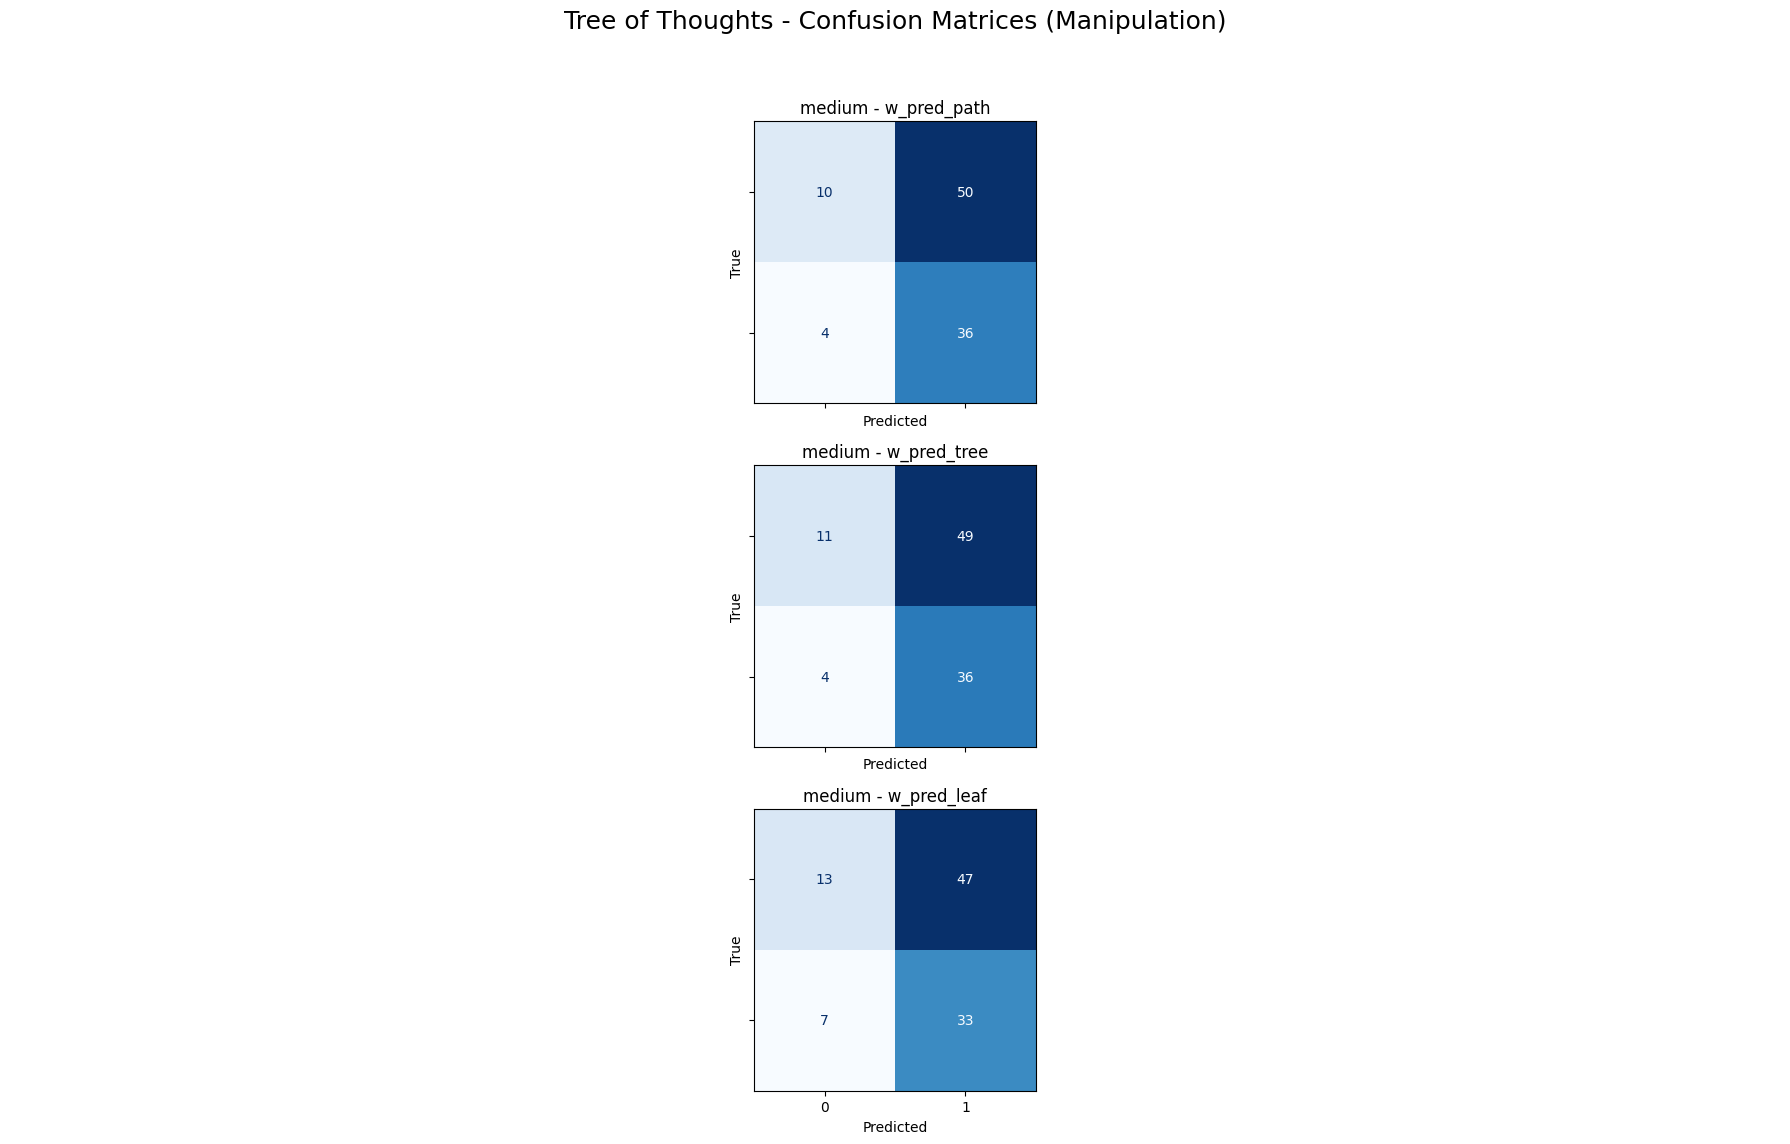


=== Accuracy Table ===
        w_pred_path_acc  w_pred_tree_acc  w_pred_leaf_acc
regime                                                   
medium             0.46             0.47             0.46


In [4]:
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Parameters
results_dir = "results"
evaluation_methods = ["w_pred_path", "w_pred_tree", "w_pred_leaf"]
max_depth = 3
max_branching_factor = 2

# Load all Tree of Thoughts result files
records = []

for regime in ["low", "medium", "high"]:
    file_path = os.path.join(results_dir, regime, f"results_manipulation_{max_depth}_{max_branching_factor}.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df["regime"] = regime
        records.append(df)

# Combine all data
tot_results = pd.concat(records, ignore_index=True)

# Ensure numeric columns
tot_results["true_label"] = tot_results["true_label"].astype(int)
for method in evaluation_methods:
    tot_results[method] = tot_results[method].astype(int)

# Evaluation loop
for method in evaluation_methods:
    print(f"\n=== EVALUATION METHOD: {method} ===")
    for regime in ["low", "medium", "high"]:
        subset = tot_results[tot_results["regime"] == regime]
        if subset.empty:
            continue
        y_true = subset["true_label"]
        y_pred = subset[method]
        print(f"\n--- Regime: {regime.upper()} ---")
        print(classification_report(y_true, y_pred, digits=3))

# Plot confusion matrices for each regime and method
def plot_confusion_matrix(y_true, y_pred, title, ax):
    labels = [0, 1]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(len(evaluation_methods), 3, figsize=(18, 12), sharex=True, sharey=True)

for i, method in enumerate(evaluation_methods):
    for j, regime in enumerate(["low", "medium", "high"]):
        ax = axes[i, j]
        subset = tot_results[tot_results["regime"] == regime]
        if not subset.empty:
            y_true = subset["true_label"]
            y_pred = subset[method]
            plot_confusion_matrix(y_true, y_pred, title=f"{regime} - {method}", ax=ax)
        else:
            ax.axis("off")

fig.suptitle("Tree of Thoughts - Confusion Matrices (Manipulation)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Accuracy summary table
summary = (
    tot_results
    .assign(**{f"{method}_correct": tot_results["true_label"] == tot_results[method] for method in evaluation_methods})
    .groupby("regime")
    .agg(**{f"{method}_acc": (f"{method}_correct", "mean") for method in evaluation_methods})
    .reset_index()
)

print("\n=== Accuracy Table ===")
print(summary.set_index("regime").round(3))




=== EVALUATION METHOD: pred_path ===

--- Regime: MEDIUM ---
              precision    recall  f1-score   support

           0      0.800     0.067     0.123        60
           1      0.411     0.975     0.578        40

    accuracy                          0.430       100
   macro avg      0.605     0.521     0.350       100
weighted avg      0.644     0.430     0.305       100


=== EVALUATION METHOD: pred_tree ===

--- Regime: MEDIUM ---
              precision    recall  f1-score   support

           0      0.846     0.183     0.301        60
           1      0.437     0.950     0.598        40

    accuracy                          0.490       100
   macro avg      0.641     0.567     0.450       100
weighted avg      0.682     0.490     0.420       100


=== EVALUATION METHOD: pred_leaf ===

--- Regime: MEDIUM ---
              precision    recall  f1-score   support

           0      0.833     0.167     0.278        60
           1      0.432     0.950     0.594        

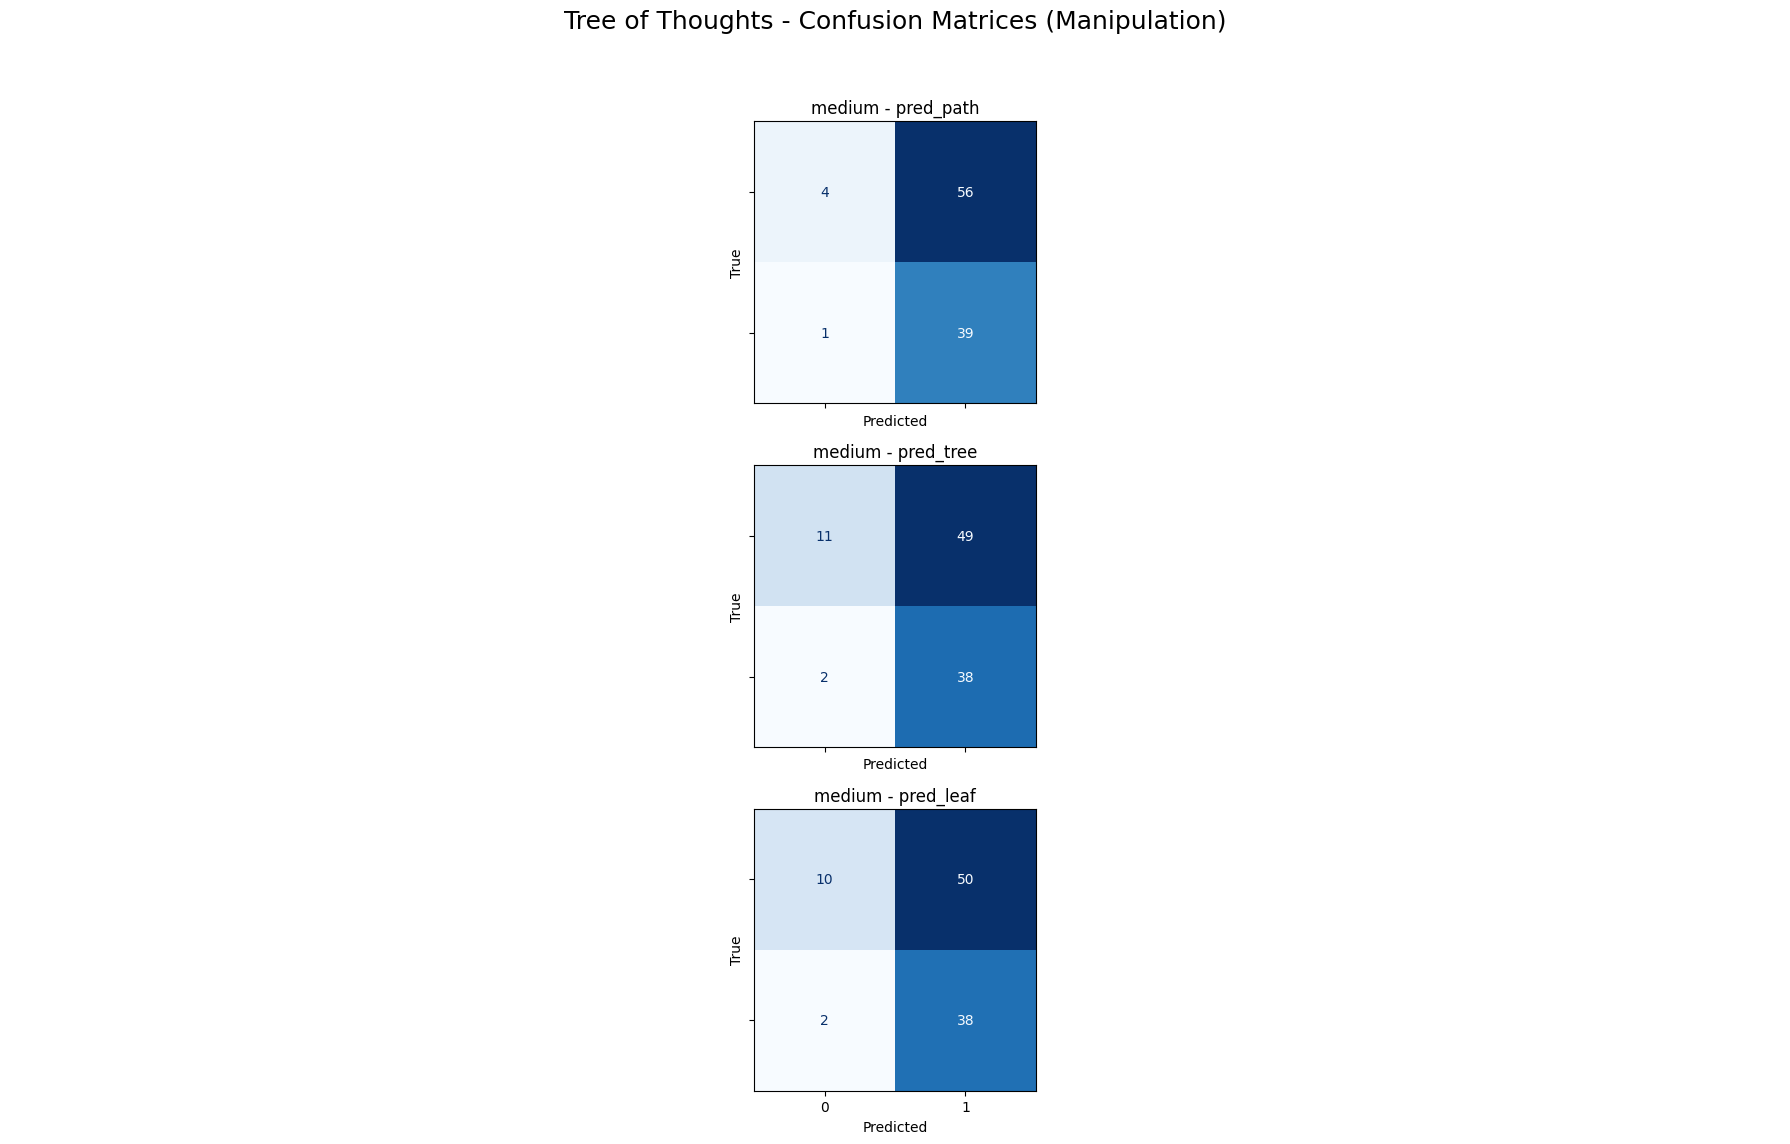


=== Accuracy Table ===
        pred_path_acc  pred_tree_acc  pred_leaf_acc
regime                                             
medium           0.43           0.49           0.48


In [ ]:
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Parameters
results_dir = "results"
evaluation_methods = ["pred_path", "pred_tree", "pred_leaf"]
max_depth = 3
max_branching_factor = 2

# Load all Tree of Thoughts result files
records = []

for regime in ["low", "medium", "high"]:
    file_path = os.path.join(results_dir, regime, f"results_manipulation_{max_depth}_{max_branching_factor}.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df["regime"] = regime
        records.append(df)

# Combine all data
tot_results = pd.concat(records, ignore_index=True)

# Ensure numeric columns
tot_results["true_label"] = tot_results["true_label"].astype(int)
for method in evaluation_methods:
    tot_results[method] = tot_results[method].astype(int)

# Evaluation loop
for method in evaluation_methods:
    print(f"\n=== EVALUATION METHOD: {method} ===")
    for regime in ["low", "medium", "high"]:
        subset = tot_results[tot_results["regime"] == regime]
        if subset.empty:
            continue
        y_true = subset["true_label"]
        y_pred = subset[method]
        print(f"\n--- Regime: {regime.upper()} ---")
        print(classification_report(y_true, y_pred, digits=3))

# Plot confusion matrices for each regime and method
def plot_confusion_matrix(y_true, y_pred, title, ax):
    labels = [0, 1]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(len(evaluation_methods), 3, figsize=(18, 12), sharex=True, sharey=True)

for i, method in enumerate(evaluation_methods):
    for j, regime in enumerate(["low", "medium", "high"]):
        ax = axes[i, j]
        subset = tot_results[tot_results["regime"] == regime]
        if not subset.empty:
            y_true = subset["true_label"]
            y_pred = subset[method]
            plot_confusion_matrix(y_true, y_pred, title=f"{regime} - {method}", ax=ax)
        else:
            ax.axis("off")

fig.suptitle("Tree of Thoughts - Confusion Matrices (Manipulation)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Accuracy summary table
summary = (
    tot_results
    .assign(**{f"{method}_correct": tot_results["true_label"] == tot_results[method] for method in evaluation_methods})
    .groupby("regime")
    .agg(**{f"{method}": (f"{method}_correct", "mean") for method in evaluation_methods})
    .reset_index()
)

print("\n=== Accuracy Table ===")
print(summary.set_index("regime").round(3))
